# 07 – Modelling: Árbol de Decisión y Random Forest

**Proyecto:** Encuesta Permanente de Empleo Nacional (EPEN)  
**Objetivo:** Entrenar y optimizar un Árbol de Decisión y un Random Forest para clasificar la condición de desocupación, comparando su desempeño con el modelo baseline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, roc_curve
)
import joblib
import os

SEL_DIR = os.path.join('..', 'data', 'selected')
SPLIT_DIR = os.path.join('..', 'data', 'split')
TARGET = 'target_desocupado'

try:
    df_train = pd.read_csv(os.path.join(SEL_DIR, 'epen_selected.csv'))
    X_test = pd.read_csv(os.path.join(SPLIT_DIR, 'X_test.csv'))
    y_test = pd.read_csv(os.path.join(SPLIT_DIR, 'y_test.csv')).squeeze()
    selected = pd.read_csv(os.path.join(SEL_DIR, 'selected_features.csv'))['selected_feature'].tolist()
    X_train = df_train[[c for c in selected if c in df_train.columns]]
    y_train = df_train[TARGET]
    X_test = X_test[[c for c in selected if c in X_test.columns]].fillna(0)
except FileNotFoundError:
    np.random.seed(42)
    n_train, n_test, n_feat = 800, 200, 8
    X_train = pd.DataFrame(np.random.randn(n_train, n_feat), columns=[f'f{i}' for i in range(n_feat)])
    y_train = pd.Series(np.random.choice([0, 1], n_train, p=[0.50, 0.50]))
    X_test = pd.DataFrame(np.random.randn(n_test, n_feat), columns=[f'f{i}' for i in range(n_feat)])
    y_test = pd.Series(np.random.choice([0, 1], n_test, p=[0.50, 0.50]))

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (800, 8) | Test: (200, 8)


## 1. Árbol de Decisión

In [2]:
# Optimización de hiperparámetros con Cross-Validation
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [5, 10, 20],
    'class_weight': ['balanced'],
}

dt_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
dt_cv.fit(X_train, y_train)

best_dt = dt_cv.best_estimator_
print(f'Mejores parámetros DT: {dt_cv.best_params_}')
print(f'ROC-AUC CV (Train): {dt_cv.best_score_:.4f}')

Mejores parámetros DT: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 20}
ROC-AUC CV (Train): 0.5057


In [3]:
y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

print('=== Árbol de Decisión (optimizado) ===')
print(classification_report(y_test, y_pred_dt))
print(f'ROC-AUC Test: {roc_auc_score(y_test, y_prob_dt):.4f}')

=== Árbol de Decisión (optimizado) ===
              precision    recall  f1-score   support

           0       0.46      0.56      0.50        91
           1       0.55      0.45      0.49       109

    accuracy                           0.50       200
   macro avg       0.51      0.50      0.50       200
weighted avg       0.51      0.50      0.50       200

ROC-AUC Test: 0.4942


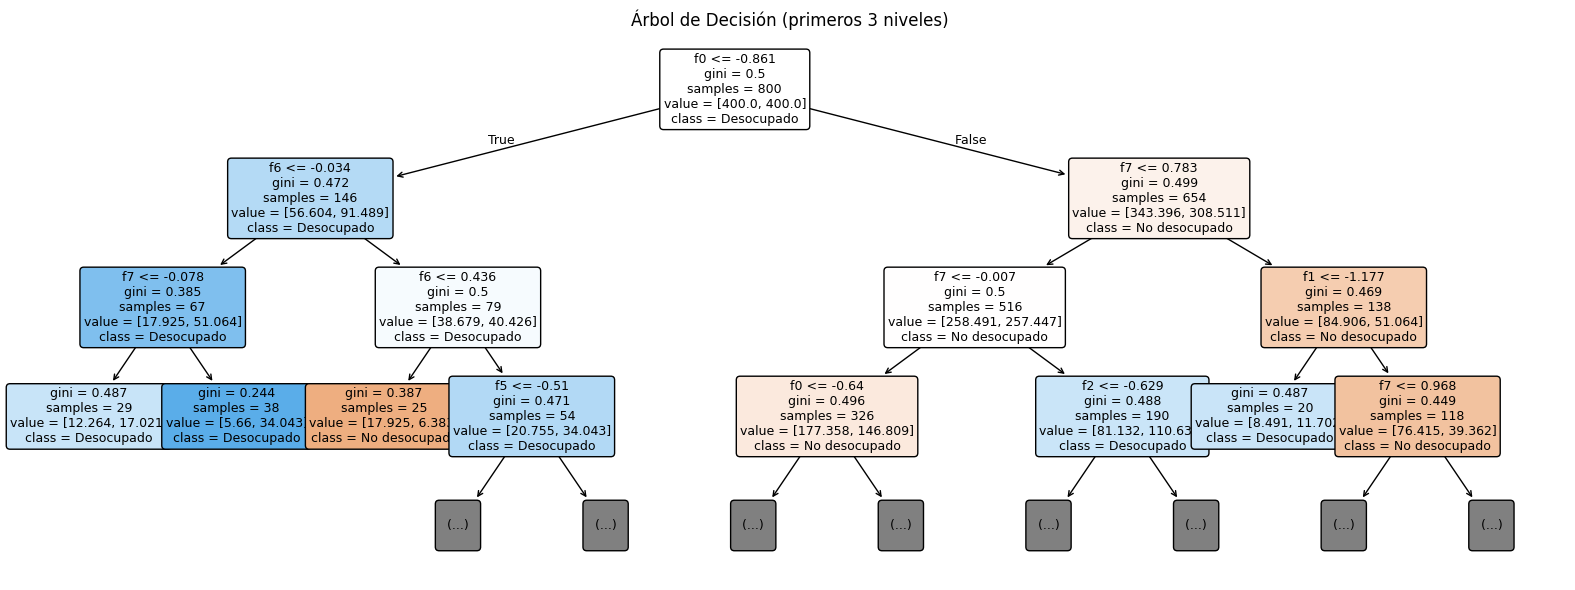

In [4]:
# Visualizar árbol (primeros 3 niveles)
plt.figure(figsize=(16, 6))
plot_tree(best_dt, max_depth=3, feature_names=X_train.columns.tolist(),
          class_names=['No desocupado', 'Desocupado'],
          filled=True, rounded=True, fontsize=9)
plt.title('Árbol de Decisión (primeros 3 niveles)')
plt.tight_layout()
plt.show()

## 2. Random Forest

In [5]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [5, 10],
    'class_weight': ['balanced'],
}

rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
rf_cv.fit(X_train, y_train)

best_rf = rf_cv.best_estimator_
print(f'Mejores parámetros RF: {rf_cv.best_params_}')
print(f'ROC-AUC CV (Train): {rf_cv.best_score_:.4f}')

Mejores parámetros RF: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 200}
ROC-AUC CV (Train): 0.4844


In [6]:
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print('=== Random Forest (optimizado) ===')
print(classification_report(y_test, y_pred_rf))
print(f'ROC-AUC Test: {roc_auc_score(y_test, y_prob_rf):.4f}')

=== Random Forest (optimizado) ===
              precision    recall  f1-score   support

           0       0.49      0.62      0.55        91
           1       0.59      0.47      0.52       109

    accuracy                           0.54       200
   macro avg       0.54      0.54      0.53       200
weighted avg       0.55      0.54      0.53       200

ROC-AUC Test: 0.5454


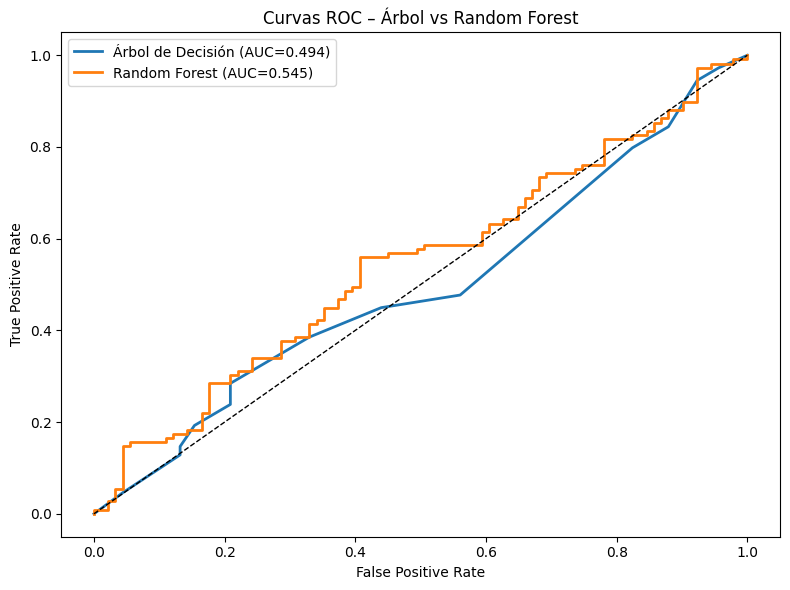

In [7]:
# Curvas ROC comparativas
plt.figure(figsize=(8, 6))
for name, y_prob in [('Árbol de Decisión', y_prob_dt), ('Random Forest', y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC – Árbol vs Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
MODEL_DIR = os.path.join('..', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(best_dt, os.path.join(MODEL_DIR, 'decision_tree.pkl'))
joblib.dump(best_rf, os.path.join(MODEL_DIR, 'random_forest.pkl'))
print('Modelos guardados: decision_tree.pkl, random_forest.pkl')

Modelos guardados: decision_tree.pkl, random_forest.pkl
